In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

base_path="/content/drive/MyDrive/truck_pooling_ai"

folders=[
    "datasets",
    "models",
    "reports",
    "outputs",
    "notebooks"
]

for folder in folders:
    os.makedirs(os.path.join(base_path,folder),exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [7]:
dataset_path="/content/drive/MyDrive/truck_pooling_ai/datasets/driver_recommendation_dataset_v2_10000.xlsx"

df=pd.read_excel(dataset_path)

df.head()

,driver_id,driver_rating,completed_trips,experience_years,on_time_delivery_percent,cancellation_rate_percent,distance_from_pickup_km,bid_amount_inr,vehicle_capacity_match_percent,return_load_success_percent,...,vehicle_age_years,truck_capacity_kg,fuel_efficiency_kmpl,previous_accidents,license_validity_years,current_active_trips,route_familiarity_percent,goods_handling_experience_percent,customer_feedback_percent,recommendation_score
0,D00001,3.3,119,25,88,3.2,100.8,12500,90,89,...,10,18000,5.5,0,3,1,81,95,80,68.81
1,D00002,4.5,197,1,88,9.3,105.6,34746,75,55,...,14,3500,4.1,0,2,5,69,68,95,53.88
2,D00003,4.8,328,14,93,5.7,56.8,12408,85,76,...,15,18000,4.7,2,1,3,92,87,91,71.31
3,D00004,4.2,845,22,94,10.7,58.9,53808,90,78,...,1,18000,8.6,1,12,0,91,76,75,76.98
4,D00005,3.8,597,13,77,8.7,47.1,32027,75,67,...,2,18000,8.5,2,1,2,74,85,87,67.88


In [8]:
print(df.shape)

(10000, 21)


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   driver_id                          10000 non-null  object 
 1   driver_rating                      10000 non-null  float64
 2   completed_trips                    10000 non-null  int64  
 3   experience_years                   10000 non-null  int64  
 4   on_time_delivery_percent           10000 non-null  int64  
 5   cancellation_rate_percent          10000 non-null  float64
 6   distance_from_pickup_km            10000 non-null  float64
 7   bid_amount_inr                     10000 non-null  int64  
 8   vehicle_capacity_match_percent     10000 non-null  int64  
 9   return_load_success_percent        10000 non-null  int64  
 10  vehicle_type                       10000 non-null  object 
 11  vehicle_age_years                  10000 non-null  int6

In [11]:
df.describe()

,driver_rating,completed_trips,experience_years,on_time_delivery_percent,cancellation_rate_percent,distance_from_pickup_km,bid_amount_inr,vehicle_capacity_match_percent,return_load_success_percent,vehicle_age_years,truck_capacity_kg,fuel_efficiency_kmpl,previous_accidents,license_validity_years,current_active_trips,route_familiarity_percent,goods_handling_experience_percent,customer_feedback_percent,recommendation_score
count,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.105530,464.348000,12.981900,87.27670,6.049780,60.447700,35056.023800,87.409000,77.54420,7.508900,6550.65000,6.482590,1.511800,8.046200,2.487800,79.925700,80.055700,85.000400,69.423290
std,0.523523,251.566856,7.249292,7.53407,3.450594,34.352253,14319.658843,8.585691,13.29647,4.633947,6322.96272,1.722599,1.118207,4.320849,1.709603,11.831085,11.778517,9.007881,6.316275
min,3.200000,30.000000,1.000000,75.00000,0.000000,1.000000,10001.000000,75.000000,55.00000,0.000000,1000.00000,3.500000,0.000000,1.000000,0.000000,60.000000,60.000000,70.000000,49.410000
25%,3.675000,248.000000,7.000000,81.00000,3.100000,30.500000,22706.500000,80.000000,66.00000,3.000000,1500.00000,5.000000,1.000000,4.000000,1.000000,70.000000,70.000000,77.000000,65.027500
50%,4.100000,463.000000,13.000000,87.00000,6.100000,60.600000,35140.000000,85.000000,77.50000,7.000000,3500.00000,6.500000,2.000000,8.000000,2.000000,80.000000,80.000000,85.000000,69.480000
75%,4.600000,684.000000,19.000000,94.00000,9.000000,90.000000,47445.750000,95.000000,89.00000,12.000000,9000.00000,7.900000,3.000000,12.000000,4.000000,90.000000,90.000000,93.000000,73.860000
max,5.000000,900.000000,25.000000,100.00000,12.000000,120.000000,59996.000000,100.000000,100.00000,15.000000,18000.00000,9.500000,3.000000,15.000000,5.000000,100.000000,100.000000,100.000000,89.480000


In [12]:
X=df.drop(columns=[
    "driver_id",
    "recommendation_score"
])

y=df["recommendation_score"]

In [13]:
categorical_columns=["vehicle_type"]

numeric_columns=[col for col in X.columns if col not in categorical_columns]

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ],
    remainder="passthrough",
    force_int_remainder_cols=False
)

In [15]:
X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.20,
random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8000, 19)
(2000, 19)


In [16]:
!pip install xgboost

In [17]:
from xgboost import XGBRegressor

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

In [18]:
model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['vehicle_type'])])),
                ('regressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=0.8, device=None,
                              early_stopping_r...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=8, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [19]:
predictions = model.predict(X_test)

In [20]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("RMSE :", rmse)
print("R² Score :", r2)

MAE : 0.8824391329193115
RMSE : 1.1237564313638202
R² Score : 0.9685052567050746


In [21]:
import joblib

model_path = "/content/drive/MyDrive/truck_pooling_ai/models/driver_recommendation.pkl"

joblib.dump(model, model_path)

print("✅ Model saved successfully.")

✅ Model saved successfully.


In [22]:
saved_model = joblib.load(model_path)

In [23]:
import pandas as pd

sample = pd.DataFrame({

"driver_rating":[4.9],
"completed_trips":[520],
"experience_years":[10],
"on_time_delivery_percent":[98],
"cancellation_rate_percent":[1],
"distance_from_pickup_km":[8],
"bid_amount_inr":[19000],
"vehicle_capacity_match_percent":[100],
"return_load_success_percent":[94],
"vehicle_type":["Container Truck"],
"vehicle_age_years":[3],
"truck_capacity_kg":[9000],
"fuel_efficiency_kmpl":[6.8],
"previous_accidents":[0],
"license_validity_years":[9],
"current_active_trips":[1],
"route_familiarity_percent":[95],
"goods_handling_experience_percent":[97],
"customer_feedback_percent":[99]

})

score = saved_model.predict(sample)

print("Recommendation Score :", round(score[0],2))

Recommendation Score : 82.63


In [24]:
sample = pd.DataFrame({

"driver_rating":[5.0],

"completed_trips":[900],

"experience_years":[20],

"on_time_delivery_percent":[100],

"cancellation_rate_percent":[0],

"distance_from_pickup_km":[1],

"bid_amount_inr":[15000],

"vehicle_capacity_match_percent":[100],

"return_load_success_percent":[100],

"vehicle_type":["Container Truck"],

"vehicle_age_years":[1],

"truck_capacity_kg":[9000],

"fuel_efficiency_kmpl":[9.5],

"previous_accidents":[0],

"license_validity_years":[15],

"current_active_trips":[0],

"route_familiarity_percent":[100],

"goods_handling_experience_percent":[100],

"customer_feedback_percent":[100]

})

print(saved_model.predict(sample))

[90.650276]


In [25]:
import joblib

joblib.dump(
    model,
    "/content/drive/MyDrive/truck_pooling_ai/models/driver_recommendation.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [26]:
metrics = f"""
AI DRIVER RECOMMENDATION MODEL

Algorithm : XGBoost Regressor

MAE : {mae}

RMSE : {rmse}

R² Score : {r2}

Dataset Size : {len(df)}
"""

with open("/content/drive/MyDrive/truck_pooling_ai/reports/model_metrics.txt","w") as f:
    f.write(metrics)

print("Metrics saved.")

Metrics saved.


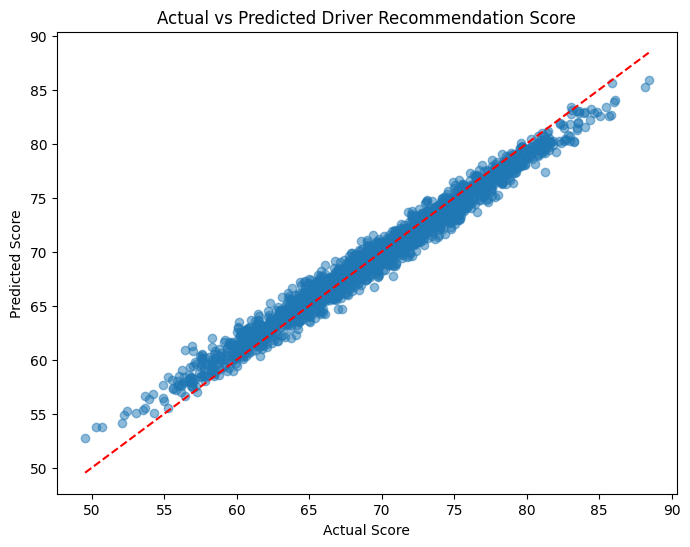

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test,predictions,alpha=0.5)

plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    'r--'
)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Driver Recommendation Score")

plt.savefig("/content/drive/MyDrive/truck_pooling_ai/reports/actual_vs_predicted.png")

plt.show()

<Figure size 1000x800 with 0 Axes>

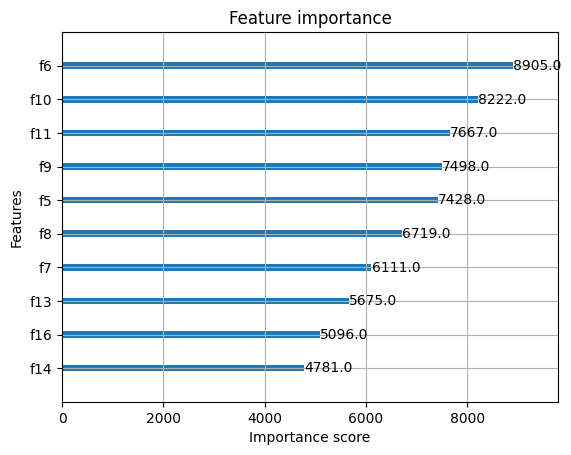

In [28]:
from xgboost import plot_importance

plt.figure(figsize=(10,8))

plot_importance(
    model.named_steps["regressor"],
    max_num_features=10
)

plt.savefig("/content/drive/MyDrive/truck_pooling_ai/reports/feature_importance.png")

plt.show()

In [29]:
sample_output = X_test.copy()

sample_output["Actual Score"] = y_test.values

sample_output["Predicted Score"] = predictions

sample_output.to_csv(
"/content/drive/MyDrive/truck_pooling_ai/outputs/sample_predictions.csv",
index=False
)